In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probjax.utils.odeint import odeint
from probjax.utils.odeutil.util import interp_fit

2024-10-27 15:05:39.715085: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


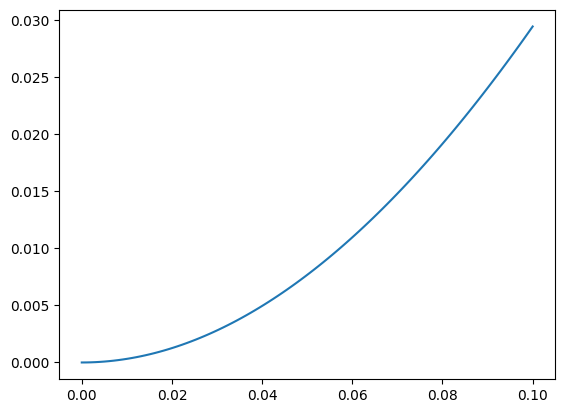

In [3]:
y0 = 0.
y1 = 1.
f0 = 0.
f1 = 2.
dt = 0.1
y_mid = 0.5

coeff = interp_fit(y0,y1,f0,f1, dt, y_mid=y_mid)
_f = jax.vmap(lambda t: jnp.polyval(coeff, t))
ts = jnp.linspace(0,dt,100)

plt.plot(ts, _f(ts))

In [4]:
def optimal_step_size(last_step, mean_error_ratio, safety=0.9, ifactor=10.0,
                      dfactor=0.2, order=5.0):
  """Compute optimal Runge-Kutta stepsize."""
  dfactor = jnp.where(mean_error_ratio < 1, 1.0, dfactor)

  factor = jnp.minimum(ifactor,
                      jnp.maximum(mean_error_ratio**(-1.0 / order) * safety, dfactor))
  return jnp.where(mean_error_ratio == 0, last_step * ifactor, last_step * factor)

float(optimal_step_size(2e-5, 1.1, order=5))

1.766013156156987e-05

In [13]:
def f(t, y):
    return -y

y0 = jnp.ones(1)*10.

t = jnp.linspace(0, 1, 10)
y = odeint(f, y0, t,method="imp_crank_nicolson")

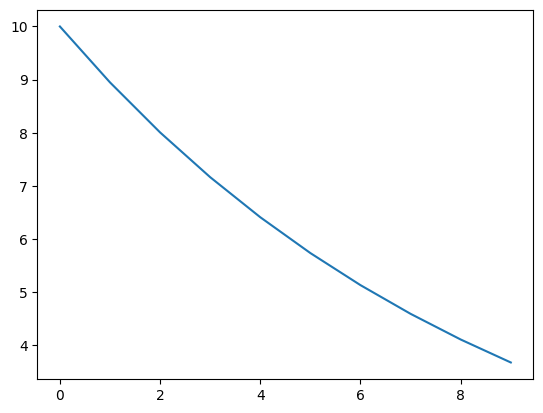

In [14]:
plt.plot(y)

In [38]:
# Copyright 2018 The JAX Authors.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

"""JAX-based Dormand-Prince ODE integration with adaptive stepsize.

Integrate systems of ordinary differential equations (ODEs) using the JAX
autograd/diff library and the Dormand-Prince method for adaptive integration
stepsize calculation. Provides improved integration accuracy over fixed
stepsize integration methods.

For details of the mixed 4th/5th order Runge-Kutta integration method, see
https://doi.org/10.1090/S0025-5718-1986-0815836-3

Adjoint algorithm based on Appendix C of https://arxiv.org/pdf/1806.07366.pdf
"""


import operator as op
from functools import partial

import jax
import jax.numpy as jnp
from jax import custom_derivatives, lax
from jax._src import core
from jax._src import linear_util as lu
from jax._src.numpy.util import promote_dtypes_inexact
from jax._src.util import safe_map, safe_zip
from jax.flatten_util import ravel_pytree
from jax.tree_util import tree_leaves, tree_map

map = safe_map
zip = safe_zip


def ravel_first_arg(f, unravel):
  return ravel_first_arg_(lu.wrap_init(f), unravel).call_wrapped

@lu.transformation
def ravel_first_arg_(unravel, y_flat, *args):
  y = unravel(y_flat)
  ans = yield (y,) + args, {}
  ans_flat, _ = ravel_pytree(ans)
  yield ans_flat

def interp_fit_dopri(y0, y1, k, dt):
  # Fit a polynomial to the results of a Runge-Kutta step.
  dps_c_mid = jnp.array([
      6025192743 / 30085553152 / 2, 0, 51252292925 / 65400821598 / 2,
      -2691868925 / 45128329728 / 2, 187940372067 / 1594534317056 / 2,
      -1776094331 / 19743644256 / 2, 11237099 / 235043384 / 2], dtype=y0.dtype)
  y_mid = y0 + dt.astype(y0.dtype) * jnp.dot(dps_c_mid, k)
  return jnp.asarray(fit_4th_order_polynomial(y0, y1, y_mid, k[0], k[-1], dt))

def fit_4th_order_polynomial(y0, y1, y_mid, dy0, dy1, dt):
  dt = dt.astype(y0.dtype)
  a = -2.*dt*dy0 + 2.*dt*dy1 -  8.*y0 -  8.*y1 + 16.*y_mid
  b =  5.*dt*dy0 - 3.*dt*dy1 + 18.*y0 + 14.*y1 - 32.*y_mid
  c = -4.*dt*dy0 +    dt*dy1 - 11.*y0 -  5.*y1 + 16.*y_mid
  d = dt * dy0
  e = y0
  return a, b, c, d, e

def initial_step_size(fun, t0, y0, order, rtol, atol, f0):
  # Algorithm from:
  # E. Hairer, S. P. Norsett G. Wanner,
  # Solving Ordinary Differential Equations I: Nonstiff Problems, Sec. II.4.
  y0, f0 = promote_dtypes_inexact(y0, f0)
  dtype = y0.dtype

  scale = atol + jnp.abs(y0) * rtol
  d0 = jnp.linalg.norm(y0 / scale.astype(dtype))
  d1 = jnp.linalg.norm(f0 / scale.astype(dtype))

  h0 = jnp.where((d0 < 1e-5) | (d1 < 1e-5), 1e-6, 0.01 * d0 / d1)
  y1 = y0 + h0.astype(dtype) * f0
  f1 = fun(y1, t0 + h0)
  d2 = jnp.linalg.norm((f1 - f0) / scale.astype(dtype)) / h0

  h1 = jnp.where((d1 <= 1e-15) & (d2 <= 1e-15),
                jnp.maximum(1e-6, h0 * 1e-3),
                (0.01 / jnp.maximum(d1, d2)) ** (1. / (order + 1.)))

  return jnp.minimum(100. * h0, h1)

def runge_kutta_step(func, y0, f0, t0, dt):
  # Dopri5 Butcher tableaux
  alpha = jnp.array([1 / 5, 3 / 10, 4 / 5, 8 / 9, 1., 1., 0], dtype=dt.dtype)
  beta = jnp.array(
      [[1 / 5, 0, 0, 0, 0, 0, 0], [3 / 40, 9 / 40, 0, 0, 0, 0, 0],
       [44 / 45, -56 / 15, 32 / 9, 0, 0, 0, 0],
       [19372 / 6561, -25360 / 2187, 64448 / 6561, -212 / 729, 0, 0, 0],
       [9017 / 3168, -355 / 33, 46732 / 5247, 49 / 176, -5103 / 18656, 0, 0],
       [35 / 384, 0, 500 / 1113, 125 / 192, -2187 / 6784, 11 / 84, 0]],
      dtype=f0.dtype)
  c_sol = jnp.array(
      [35 / 384, 0, 500 / 1113, 125 / 192, -2187 / 6784, 11 / 84, 0],
      dtype=f0.dtype)
  c_error = jnp.array([
      35 / 384 - 1951 / 21600, 0, 500 / 1113 - 22642 / 50085, 125 / 192 -
      451 / 720, -2187 / 6784 - -12231 / 42400, 11 / 84 - 649 / 6300, -1. / 60.
  ], dtype=f0.dtype)

  def body_fun(i, k):
    ti = t0 + dt * alpha[i-1]
    yi = y0 + dt.astype(f0.dtype) * jnp.dot(beta[i-1, :], k)
    ft = func(yi, ti)
    return k.at[i, :].set(ft)

  k = jnp.zeros((7, f0.shape[0]), f0.dtype).at[0, :].set(f0)
  k = lax.fori_loop(1, 7, body_fun, k)

  y1 = dt.astype(f0.dtype) * jnp.dot(c_sol, k) + y0
  y1_error = dt.astype(f0.dtype) * jnp.dot(c_error, k)
  f1 = k[-1]
  return y1, f1, y1_error, k

def abs2(x):
  if jnp.iscomplexobj(x):
    return x.real ** 2 + x.imag ** 2
  else:
    return x ** 2

def mean_error_ratio(error_estimate, rtol, atol, y0, y1):
  err_tol = atol + rtol * jnp.maximum(jnp.abs(y0), jnp.abs(y1))
  err_ratio = error_estimate / err_tol.astype(error_estimate.dtype)
  return jnp.sqrt(jnp.mean(abs2(err_ratio)))

def optimal_step_size(last_step, mean_error_ratio, safety=0.9, ifactor=10.0,
                      dfactor=0.2, order=5.0):
  """Compute optimal Runge-Kutta stepsize."""
  dfactor = jnp.where(mean_error_ratio < 1, 1.0, dfactor)

  factor = jnp.minimum(ifactor,
                      jnp.maximum(mean_error_ratio**(-1.0 / order) * safety, dfactor))
  return jnp.where(mean_error_ratio == 0, last_step * ifactor, last_step * factor)

def odeint(func, y0, t, *args, rtol=1.4e-8, atol=1.4e-8, mxstep=jnp.inf, hmax=jnp.inf):
  """Adaptive stepsize (Dormand-Prince) Runge-Kutta odeint implementation.

  Args:
    func: function to evaluate the time derivative of the solution `y` at time
      `t` as `func(y, t, *args)`, producing the same shape/structure as `y0`.
    y0: array or pytree of arrays representing the initial value for the state.
    t: array of float times for evaluation, like `jnp.linspace(0., 10., 101)`,
      in which the values must be strictly increasing.
    *args: tuple of additional arguments for `func`, which must be arrays
      scalars, or (nested) standard Python containers (tuples, lists, dicts,
      namedtuples, i.e. pytrees) of those types.
    rtol: float, relative local error tolerance for solver (optional).
    atol: float, absolute local error tolerance for solver (optional).
    mxstep: int, maximum number of steps to take for each timepoint (optional).
    hmax: float, maximum step size allowed (optional).

  Returns:
    Values of the solution `y` (i.e. integrated system values) at each time
    point in `t`, represented as an array (or pytree of arrays) with the same
    shape/structure as `y0` except with a new leading axis of length `len(t)`.
  """
  for arg in tree_leaves(args):
    if not isinstance(arg, core.Tracer) and not core.valid_jaxtype(arg):
      raise TypeError(
        f"The contents of odeint *args must be arrays or scalars, but got {arg}.")
  if not jnp.issubdtype(t.dtype, jnp.floating):
    raise TypeError(f"t must be an array of floats, but got {t}.")

  converted, consts = custom_derivatives.closure_convert(func, y0, t[0], *args)
  return _odeint_wrapper(converted, rtol, atol, mxstep, hmax, y0, t, *args, *consts)

@partial(jax.jit, static_argnums=(0, 1, 2, 3, 4))
def _odeint_wrapper(func, rtol, atol, mxstep, hmax, y0, ts, *args):
  y0, unravel = ravel_pytree(y0)
  func = ravel_first_arg(func, unravel)
  out = _odeint(func, rtol, atol, mxstep, hmax, y0, ts, *args)
  return jax.vmap(unravel)(out)

@partial(jax.custom_vjp, nondiff_argnums=(0, 1, 2, 3, 4))
def _odeint(func, rtol, atol, mxstep, hmax, y0, ts, *args):
  func_ = lambda y, t: func(y, t, *args)

  def scan_fun(carry, target_t):

    def cond_fun(state):
      i, _, _, t, dt, _, _ = state
      return (t < target_t) & (i < mxstep) & (dt > 0)

    def body_fun(state):
      i, y, f, t, dt, last_t, interp_coeff = state
      next_y, next_f, next_y_error, k = runge_kutta_step(func_, y, f, t, dt)
      next_t = t + dt
      error_ratio = mean_error_ratio(next_y_error, rtol, atol, y, next_y)
      new_interp_coeff = interp_fit_dopri(y, next_y, k, dt)
      dt = jnp.clip(optimal_step_size(dt, error_ratio), min=0., max=hmax)

      new = [i + 1, next_y, next_f, next_t, dt,      t, new_interp_coeff]
      old = [i + 1,      y,      f,      t, dt, last_t,     interp_coeff]
      return map(partial(jnp.where, error_ratio <= 1.), new, old)

    _, *carry = lax.while_loop(cond_fun, body_fun, [0] + carry)
    _, _, t, _, last_t, interp_coeff = carry
    relative_output_time = (target_t - last_t) / (t - last_t)
    jax.debug.print(
      "t={t}, last_t={last_t}, target_t={target_t}, relative_output_time={relative_output_time}",
      t=t, last_t=last_t, target_t=target_t, relative_output_time=relative_output_time
    )
    y_target = jnp.polyval(interp_coeff, relative_output_time.astype(interp_coeff.dtype))
    return carry, y_target

  f0 = func_(y0, ts[0])
  dt = jnp.clip(initial_step_size(func_, ts[0], y0, 4, rtol, atol, f0), min=0., max=hmax)
  interp_coeff = jnp.array([y0] * 5)
  init_carry = [y0, f0, ts[0], dt, ts[0], interp_coeff]
  _, ys = lax.scan(scan_fun, init_carry, ts[1:])
  return jnp.concatenate((y0[None], ys))

def _odeint_fwd(func, rtol, atol, mxstep, hmax, y0, ts, *args):
  ys = _odeint(func, rtol, atol, mxstep, hmax, y0, ts, *args)
  return ys, (ys, ts, args)

def _odeint_rev(func, rtol, atol, mxstep, hmax, res, g):
  ys, ts, args = res

  def aug_dynamics(augmented_state, t, *args):
    """Original system augmented with vjp_y, vjp_t and vjp_args."""
    y, y_bar, *_ = augmented_state
    # `t` here is negatice time, so we need to negate again to get back to
    # normal time. See the `odeint` invocation in `scan_fun` below.
    y_dot, vjpfun = jax.vjp(func, y, -t, *args)
    return (-y_dot, *vjpfun(y_bar))

  y_bar = g[-1]
  ts_bar = []
  t0_bar = 0.

  def scan_fun(carry, i):
    y_bar, t0_bar, args_bar = carry
    # Compute effect of moving measurement time
    # `t_bar` should not be complex as it represents time
    t_bar = jnp.dot(func(ys[i], ts[i], *args), g[i]).real
    t0_bar = t0_bar - t_bar
    # Run augmented system backwards to previous observation
    _, y_bar, t0_bar, args_bar = odeint(
        aug_dynamics, (ys[i], y_bar, t0_bar, args_bar),
        jnp.array([-ts[i], -ts[i - 1]]),
        *args, rtol=rtol, atol=atol, mxstep=mxstep, hmax=hmax)
    y_bar, t0_bar, args_bar = tree_map(op.itemgetter(1), (y_bar, t0_bar, args_bar))
    # Add gradient from current output
    y_bar = y_bar + g[i - 1]
    return (y_bar, t0_bar, args_bar), t_bar

  init_carry = (g[-1], 0., tree_map(jnp.zeros_like, args))
  (y_bar, t0_bar, args_bar), rev_ts_bar = lax.scan(
      scan_fun, init_carry, jnp.arange(len(ts) - 1, 0, -1))
  ts_bar = jnp.concatenate([jnp.array([t0_bar]), rev_ts_bar[::-1]])
  return (y_bar, ts_bar, *args_bar)

_odeint.defvjp(_odeint_fwd, _odeint_rev)

In [18]:
def f(t, y):
    return -y

y0 = jnp.ones(1)*10.

t = jnp.linspace(0, 2, 3)
y = odeint(f, y0, t, atol=1e-4, rtol=1e-5)

t=1.1110999584197998, last_t=0.11109999567270279, target_t=1.0, relative_output_time=0.888900101184845
t=8.438862800598145, last_t=1.1110999584197998, target_t=2.0, relative_output_time=0.12130579352378845
